[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-09/09-09-Autoencoder-and-t-SNE-for-Customer-Feedback-Analysis.ipynb)

End-to-End Example 2: Using an Autoencoder and t-SNE to Analyze Customer Feedback. Train an autoencoder to compress simulated customer-review embeddings, then use t-SNE to visualize hidden patterns and possible clusters in two dimensions. This example demonstrates unsupervised representation learning, dimensionality reduction, visualization, and human interpretation of unlabeled customer feedback.

Original data shape: torch.Size([10000, 50])
Epoch [20/100], Loss: 0.6469
Epoch [40/100], Loss: 0.3141
Epoch [60/100], Loss: 0.1963
Epoch [80/100], Loss: 0.1809
Epoch [100/100], Loss: 0.1791

Autoencoder training complete.
Compressed latent vector shape: (10000, 10)
t-SNE output shape: (10000, 2)


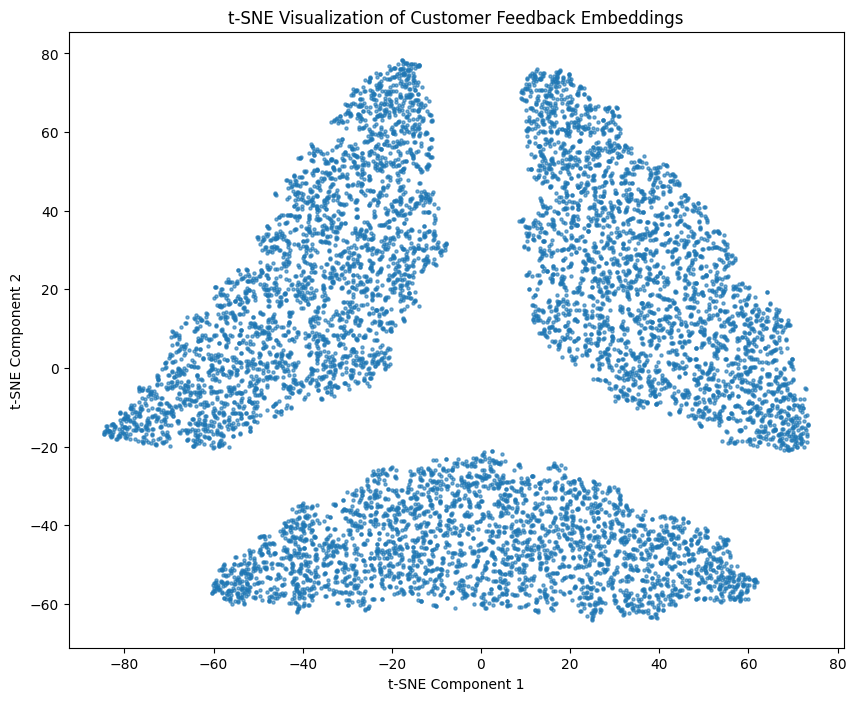

A plot has been generated showing possible clusters of reviews.


In [1]:

# Import libraries
import torch
import torch.nn as nn
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------
# 1. Prepare the Data (Simulated Review Embeddings)
# -------------------------------------------------------
# In a real-world project, a pretrained language model such as BERT
# could convert each review into an embedding vector.
# Here, we simulate 10,000 review embeddings with 50 dimensions.
# We create three hidden groups to represent:
# 1. Positive feedback
# 2. Negative feedback
# 3. Product or support questions

num_reviews = 10000
review_dim = 50

np.random.seed(42)
torch.manual_seed(42)

positive_feedback = np.random.normal(
    loc=1.0,
    scale=0.5,
    size=(num_reviews // 3, review_dim)
)

negative_feedback = np.random.normal(
    loc=-1.0,
    scale=0.5,
    size=(num_reviews // 3, review_dim)
)

question_feedback = np.random.normal(
    loc=0.0,
    scale=0.2,
    size=(num_reviews - 2 * (num_reviews // 3), review_dim)
)

review_vectors = np.concatenate(
    [positive_feedback, negative_feedback, question_feedback],
    axis=0
)

review_vectors_tensor = torch.tensor(review_vectors, dtype=torch.float32)

print(f"Original data shape: {review_vectors_tensor.shape}")

# -------------------------------------------------------
# 2. Build and Train a Simple Autoencoder
# -------------------------------------------------------
# The autoencoder compresses each 50-dimensional embedding into
# a smaller 10-dimensional latent vector, then tries to reconstruct
# the original 50-dimensional embedding.

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 30),
            nn.ReLU(),
            nn.Linear(30, input_dim)
        )

    def forward(self, x):
        latent_vector = self.encoder(x)
        reconstructed_x = self.decoder(latent_vector)
        return reconstructed_x, latent_vector

autoencoder = Autoencoder(input_dim=review_dim, latent_dim=10)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

num_epochs = 100

for epoch in range(num_epochs):
    reconstructed_data, _ = autoencoder(review_vectors_tensor)

    loss = criterion(reconstructed_data, review_vectors_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

print("\nAutoencoder training complete.")

# -------------------------------------------------------
# 3. Extract the Latent Vectors
# -------------------------------------------------------
# The encoder now gives us compressed 10-dimensional vectors.
# These are learned representations of the original review embeddings.

autoencoder.eval()

with torch.no_grad():
    _, latent_vectors = autoencoder(review_vectors_tensor)
    latent_vectors_np = latent_vectors.numpy()

print(f"Compressed latent vector shape: {latent_vectors_np.shape}")

# -------------------------------------------------------
# 4. Use t-SNE to Reduce to 2D for Visualization
# -------------------------------------------------------
# t-SNE maps the 10-dimensional latent vectors into 2D coordinates.
# This step is for visualization, not for training the model.

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)

two_d_coordinates = tsne.fit_transform(latent_vectors_np)

print(f"t-SNE output shape: {two_d_coordinates.shape}")

# -------------------------------------------------------
# 5. Visualize the Results
# -------------------------------------------------------
plt.figure(figsize=(10, 8))

plt.scatter(
    two_d_coordinates[:, 0],
    two_d_coordinates[:, 1],
    s=5,
    alpha=0.6
)

plt.title("t-SNE Visualization of Customer Feedback Embeddings")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

print("A plot has been generated showing possible clusters of reviews.")

# -------------------------------------------------------
# How do we know what each cluster means?
# -------------------------------------------------------
# Since this is unsupervised learning, the model does not know the names
# of the clusters. A human must inspect examples from each group.
#
# In a real project, you would:
# 1. Pick several points near the center of each cluster.
# 2. Find the original reviews corresponding to those points.
# 3. Read a few examples.
# 4. Assign an interpretation, such as:
#    - positive feedback
#    - complaints
#    - product questions
